<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Week8_Participation_Exercise_Lacey_Wang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Internet Sales forecast for the next five years**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving InternetSales (1).csv to InternetSales (1) (1).csv


In [21]:
data = pd.read_csv("InternetSales (1).csv", encoding='latin-1', dtype={'14': str})

/tmp/ipython-input-1135753632.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("InternetSales (1).csv", encoding='latin-1', dtype={'14': str})


/tmp/ipython-input-237954198.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.groupby(pd.Grouper(key='OrderDate', freq='M'))['SalesAmount'].sum()


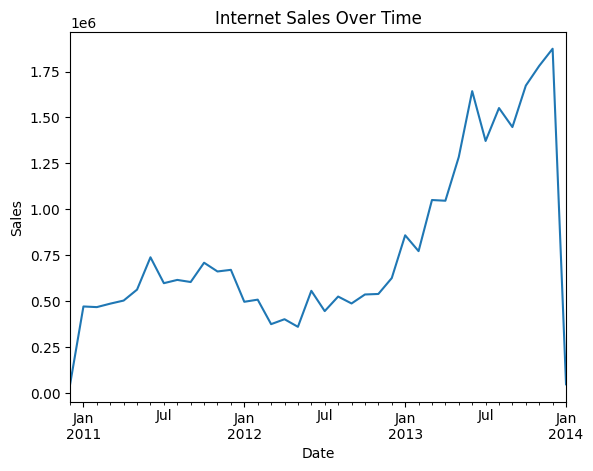

In [22]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'])
monthly_sales = data.groupby(pd.Grouper(key='OrderDate', freq='M'))['SalesAmount'].sum()
sales_series = pd.Series(monthly_sales.values, index=monthly_sales.index, name='InternetSales')

sales_series.plot(title='Internet Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# **ARIMA Method**

In [23]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_series, order=(5,1,2))
fitted_model = model.fit()
print(fitted_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:          InternetSales   No. Observations:                   38
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -520.772
Date:                Sat, 01 Nov 2025   AIC                           1057.544
Time:                        22:48:20   BIC                           1070.431
Sample:                    12-31-2010   HQIC                          1062.087
                         - 01-31-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3383      1.405      0.241      0.810      -2.416       3.092
ar.L2         -0.3571      1.254     -0.285      0.776      -2.815       2.101
ar.L3         -0.3812      1.214     -0.314      0.7

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
forecast = fitted_model.get_forecast(steps=60)
forecast_df = forecast.summary_frame()
forecast_df.head()

InternetSales,mean,mean_se,mean_ci_lower,mean_ci_upper
2014-02-28,1.317593e+06,324520.908571,681544.174775,1.953643e+06
2014-03-31,1.000861e+06,336235.630080,341851.542387,1.659871e+06
2014-04-30,1.166937e+06,388321.354640,405840.888595,1.928033e+06
2014-05-31,2.135592e+05,432685.999785,-634489.727315,1.061608e+06
2014-06-30,4.312025e+05,559731.806048,-665851.669070,1.528257e+06


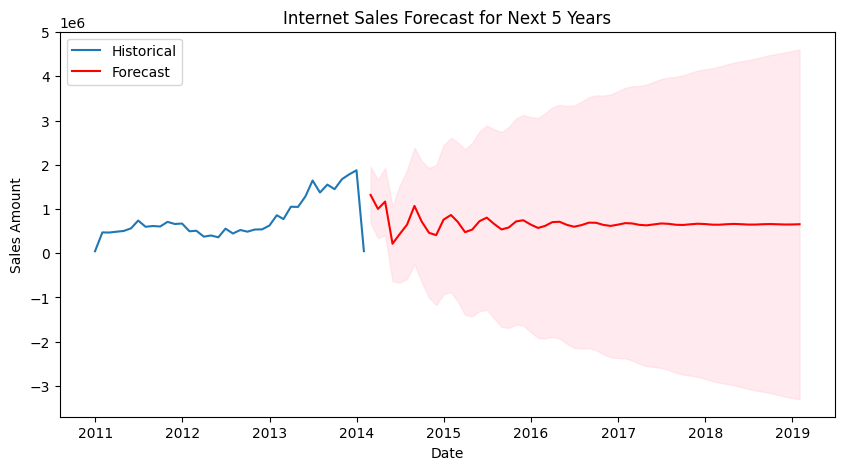

In [25]:
plt.figure(figsize=(10,5))
plt.plot(sales_series.index, sales_series, label='Historical')
plt.plot(forecast_df.index, forecast_df['mean'], color='red', label='Forecast')
plt.fill_between(forecast_df.index,
                 forecast_df['mean_ci_lower'],
                 forecast_df['mean_ci_upper'],
                 color='pink', alpha=0.3)
plt.title('Internet Sales Forecast for Next 5 Years')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.show()

# **Exponential Smoothing Method**

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

model = ExponentialSmoothing(sales_series,
                             trend='add',
                             seasonal=None,
                             initialization_method="estimated")

fitted_model = model.fit(optimized=True)
forecast = fitted_model.forecast(steps=60)
print(fitted_model.summary())




                       ExponentialSmoothing Model Results                       
Dep. Variable:            InternetSales   No. Observations:                   38
Model:             ExponentialSmoothing   SSE                  4035973463716.038
Optimized:                         True   AIC                            972.770
Trend:                         Additive   BIC                            979.320
Seasonal:                          None   AICC                           975.480
Seasonal Periods:                  None   Date:                 Sat, 01 Nov 2025
Box-Cox:                          False   Time:                         22:48:20
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5043190                alpha                 True
smoothing_trend             0.0000

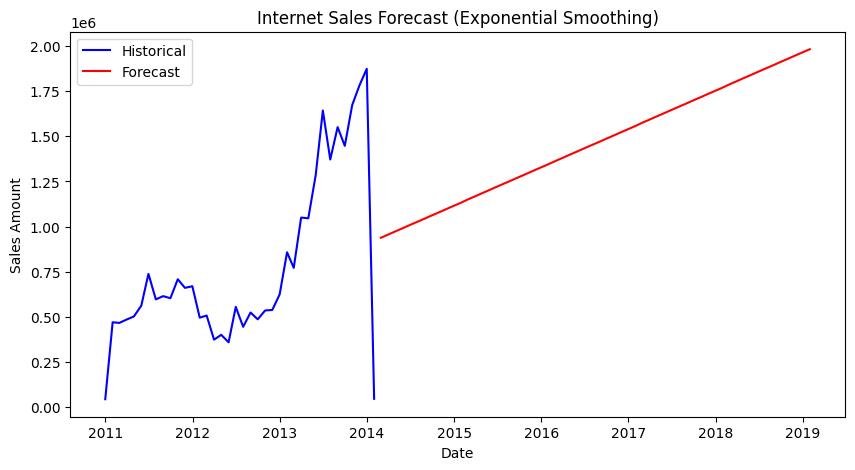

In [27]:
plt.figure(figsize=(10,5))
plt.plot(sales_series.index, sales_series, label='Historical', color='blue')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('Internet Sales Forecast (Exponential Smoothing)')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.show()

# **Which product will generate the most sales?**

**Method A: use Rolling Mean Method(Simple Average Approach)**

In [28]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'], errors='coerce')
data['SalesAmount'] = pd.to_numeric(data['SalesAmount'], errors='coerce')

prod_col = 'ProductKey'
sales_col = 'SalesAmount'

monthly = (
    data
      .groupby([pd.Grouper(key='OrderDate', freq='M'), prod_col])[sales_col]
      .sum()
      .unstack(fill_value=0)
)

monthly.head()

/tmp/ipython-input-3423068295.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(key='OrderDate', freq='M'), prod_col])[sales_col]


ProductKey,214,217,222,225,228,231,234,237,310,311,...,594,595,596,597,598,599,600,604,605,606
OrderDate,,,,,,,,,,,,,,,,,,,,,
2010-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7156.54,3578.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,78721.94,78721.94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,107348.10,53674.05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-03-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85878.48,85878.48,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96613.29,75143.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
win = min(12, len(monthly))
recent_avg = monthly.tail(win).mean(axis=0)

forecast_5yr = recent_avg * 12 * 5

forecast_df = pd.DataFrame({
    'ProductKey': forecast_5yr.index,
    'Forecast5yrSales': forecast_5yr.values
}).sort_values(by='Forecast5yrSales', ascending=False)

print("Top 10 Predicted Products by Total Sales in Next 5 Years:")
forecast_df.head(10)

Top 10 Predicted Products by Total Sales in Next 5 Years:


,ProductKey,Forecast5yrSales
54,361,4647354.75
46,353,4454380.80
50,357,4442780.85
52,359,4429330.70
56,363,4429330.70
48,355,4257181.65
127,573,2026459.50
134,580,2007168.20
115,561,1978778.10
135,581,1922118.70


In [30]:
data[['ProductKey', 'EnglishProductName']].drop_duplicates().query("ProductKey in [361,353,357,359,363,355,573,580,561,581]")

,ProductKey,EnglishProductName
1,353,"Mountain-200 Silver, 38"
3,573,"Touring-1000 Blue, 46"
20,359,"Mountain-200 Black, 38"
21,561,"Touring-1000 Yellow, 46"
23,361,"Mountain-200 Black, 42"
33,355,"Mountain-200 Silver, 42"
45,357,"Mountain-200 Silver, 46"
96,363,"Mountain-200 Black, 46"
1842,580,"Road-350-W Yellow, 40"
3132,581,"Road-350-W Yellow, 42"


/tmp/ipython-input-2126792519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10['ProductName'] = top10['ProductKey'].map(name_map)


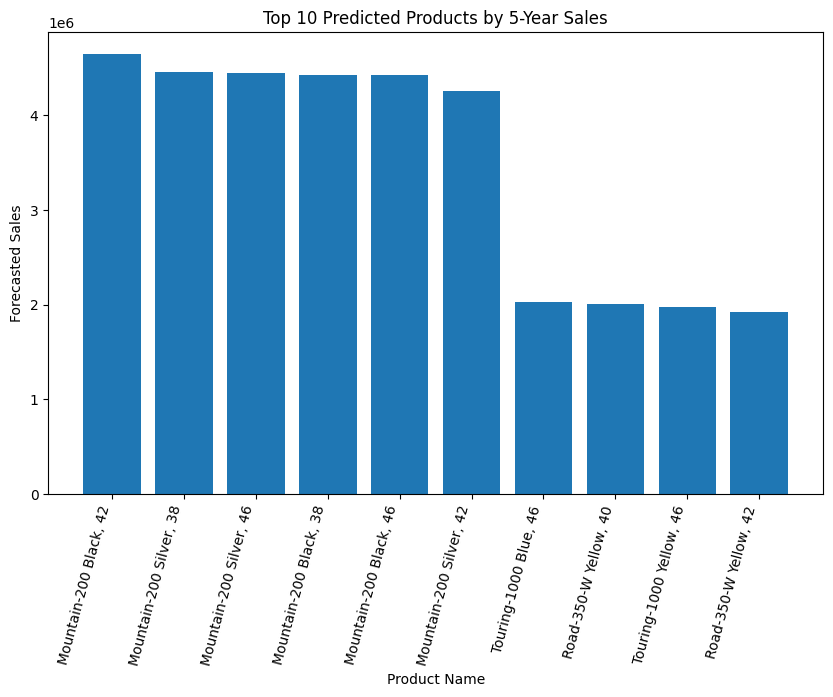

In [31]:
import matplotlib.pyplot as plt

top10 = forecast_df.head(10)

name_map = dict(zip(data['ProductKey'], data['EnglishProductName']))

top10['ProductName'] = top10['ProductKey'].map(name_map)

plt.figure(figsize=(10,6))
plt.bar(top10['ProductName'], top10['Forecast5yrSales'])
plt.title("Top 10 Predicted Products by 5-Year Sales")
plt.xlabel("Product Name")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=75, ha='right')
plt.show()

**Method B： use Holt-Winters Exponential Smoothing**

/tmp/ipython-input-716345888.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(key='OrderDate', freq='M'), 'ProductKey'])['SalesAmount']


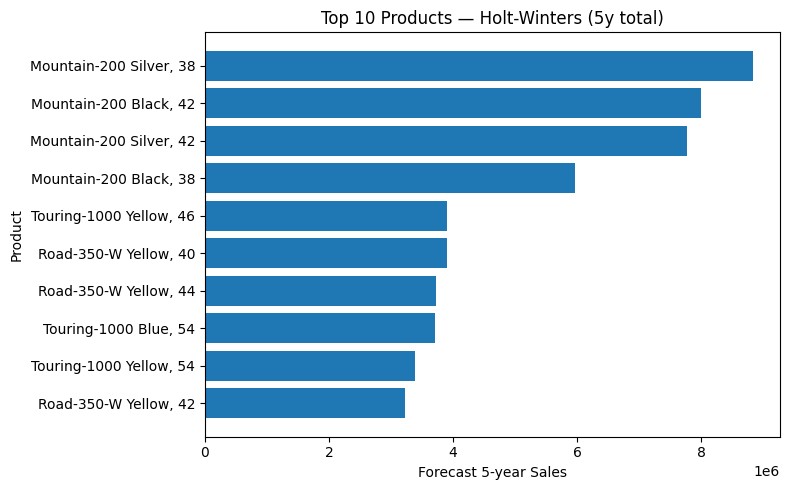

In [33]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

data['OrderDate'] = pd.to_datetime(data['OrderDate'], errors='coerce')
data['SalesAmount'] = pd.to_numeric(data['SalesAmount'], errors='coerce').fillna(0)

monthly = (data
           .groupby([pd.Grouper(key='OrderDate', freq='M'), 'ProductKey'])['SalesAmount']
           .sum()
           .unstack(fill_value=0))

hw5 = lambda s: ExponentialSmoothing(
    s.astype(float), trend='add', seasonal='add', seasonal_periods=12
).fit().forecast(60).sum()

forecast_df = (monthly.apply(hw5)
               .sort_values(ascending=False)
               .rename('Forecast5yrSales')
               .reset_index())

forecast_df = forecast_df.merge(
    data[['ProductKey','EnglishProductName']].drop_duplicates(),
    on='ProductKey', how='left'
)

plt.figure(figsize=(8,5))
plt.barh(top10['EnglishProductName'][::-1], top10['Forecast5yrSales'][::-1])
plt.xlabel('Forecast 5-year Sales'); plt.ylabel('Product')
plt.title('Top 10 Products — Holt-Winters (5y total)')
plt.tight_layout(); plt.show()

In [34]:
top10 = forecast_df.head(10)
top10[['ProductKey','EnglishProductName','Forecast5yrSales']]

,ProductKey,EnglishProductName,Forecast5yrSales
0,353,"Mountain-200 Silver, 38",8.830193e+06
1,361,"Mountain-200 Black, 42",7.997237e+06
2,355,"Mountain-200 Silver, 42",7.767058e+06
3,359,"Mountain-200 Black, 38",5.965294e+06
4,561,"Touring-1000 Yellow, 46",3.903562e+06
5,580,"Road-350-W Yellow, 40",3.896731e+06
6,582,"Road-350-W Yellow, 44",3.729517e+06
7,575,"Touring-1000 Blue, 54",3.701601e+06
8,563,"Touring-1000 Yellow, 54",3.379862e+06
9,581,"Road-350-W Yellow, 42",3.230904e+06


Initially, I planned to use a simple Rolling Mean Forecast, which takes the average sales
from the most recent 12 months as a baseline for the next five years.
This method made intuitive sense because it captures the general sales level
without adding unnecessary complexity.

However, after studying the provided forecasting examples, I learned about the
Holt-Winters Exponential Smoothing model. Unlike the mean-based approach,
Holt-Winters can capture both trend (the gradual increase or decrease in sales over time)
and seasonality (repeating yearly or monthly patterns).
By learning these patterns from historical data, it produces a more accurate and realistic
five-year forecast, especially for sales data that fluctuates across seasons.
